In [ ]:
import pandas as pd
import datetime as dt


df = pd.read_csv('data.csv', encoding='ISO-8859-1')


df = df.dropna(subset=['CustomerID'])


df = df[df['Quantity'] > 0]


df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Data successfully cleaned!")
print("Remaining rows for analysis:", df.shape[0])
display(df.head())

Data successfully cleaned!
Remaining rows for analysis: 397924


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:

latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)


rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, 
    'InvoiceNo': 'nunique',                                
    'TotalAmount': 'sum'                                   
})


rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)


display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:

r_labels = range(4, 0, -1) 
f_labels = range(1, 5)     
m_labels = range(1, 5)     


rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)


rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels) 

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)


rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

display(rfm.head())

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,6
12347.0,2,7,4310.00,4,4,4,444,12
12348.0,75,4,1797.24,2,3,4,234,9
12349.0,19,1,1757.55,3,1,4,314,8
12350.0,310,1,334.40,1,1,2,112,4


C:\Users\jesus\AppData\Local\Temp\ipykernel_24320\2393504166.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=rfm, order=['Champions', 'Loyal', 'Promising', 'At Risk', 'Lost'], palette='viridis')


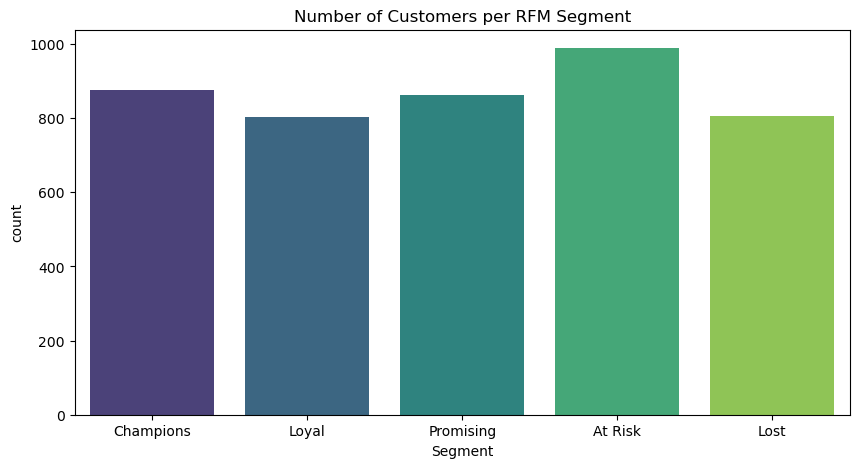

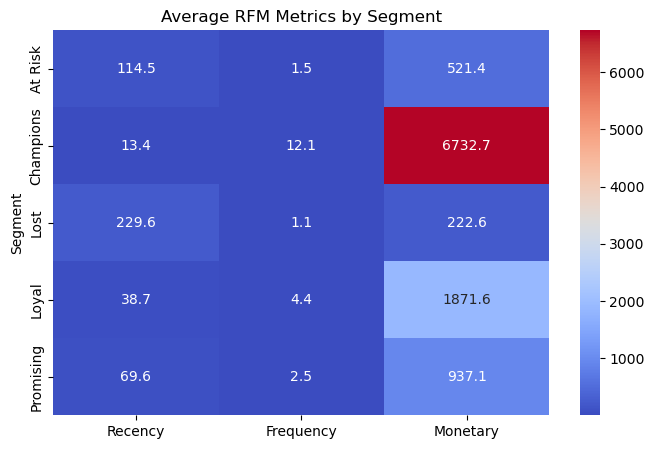

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


def rfm_level(df):
    if df['RFM_Score'] >= 11:
        return 'Champions'
    elif df['RFM_Score'] >= 9:
        return 'Loyal'
    elif df['RFM_Score'] >= 7:
        return 'Promising'
    elif df['RFM_Score'] >= 5:
        return 'At Risk'
    else:
        return 'Lost'


rfm['Segment'] = rfm.apply(rfm_level, axis=1)


plt.figure(figsize=(10,5))
sns.countplot(x='Segment', data=rfm, order=['Champions', 'Loyal', 'Promising', 'At Risk', 'Lost'], palette='viridis')
plt.title('Number of Customers per RFM Segment')
plt.show()


segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

plt.figure(figsize=(8,5))
sns.heatmap(segment_summary, annot=True, cmap='coolwarm', fmt='g')
plt.title('Average RFM Metrics by Segment')
plt.show()